# Customer Churn Analysis Using Python
### Exploratory Data Analysis and Business Insights for Customer Retention 

## Business Problem:

Customer churn represents a major business challenge in the telecom industry, directly impacting recurring revenue, customer acquisition costs, and long-term profitability.
The objective of this analysis is to identify the major factors influencing customer churn behavior and generate actionable business insights to support customer retention strategies.

## Dataset Overview:

Dataset: Telco_Customer_Churn_Dataset

The dataset contains customer demographic details, service subscriptions, billing information, contract types, payment methods, and customer churn status.

Key business objective:    
1). Understand churn behavior     
2). Identify high-risk customer groups    
3). Generate business recommendations    

In [27]:
#import python libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   #visualizing data
import seaborn as sns

## Data Loading 

In [2]:
df = pd.read_csv("C:\Data Analytics\Projects\Telco-Customer-Churn.csv")

In [3]:
df.head()

,S. No.,Customer ID,Gender,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,1,0002-ORFBO,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,No
1,2,0003-MKNFE,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,No
2,3,0004-TLHLJ,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,Yes
3,4,0011-IGKFF,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,Yes
4,5,0013-EXCHZ,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,Yes


## Dataset Dimension

In [43]:
#dimension of dataset
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 7032
Columns: 21


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S. No.             7043 non-null   int64  
 1   Customer ID        7043 non-null   object 
 2   Gender             7043 non-null   object 
 3   Senior Citizen     7043 non-null   int64  
 4   Partner            7043 non-null   object 
 5   Dependents         7043 non-null   object 
 6   Tenure             7043 non-null   int64  
 7   Phone Service      7043 non-null   object 
 8   Multiple Lines     7043 non-null   object 
 9   Internet Service   7043 non-null   object 
 10  Online Security    7043 non-null   object 
 11  Online Backup      7043 non-null   object 
 12  Device Protection  7043 non-null   object 
 13  Tech Support       7043 non-null   object 
 14  Streaming TV       7043 non-null   object 
 15  Streaming Movies   7043 non-null   object 
 16  Contract           7043 

In [6]:
#describe() return description of data in df(data frame)
df.describe()

,S. No.,Senior Citizen,Tenure,Monthly Charges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,3522.000000,0.162147,32.371149,64.761692
std,2033.283305,0.368612,24.559481,30.090047
min,1.000000,0.000000,0.000000,18.250000
25%,1761.500000,0.000000,9.000000,35.500000
50%,3522.000000,0.000000,29.000000,70.350000
75%,5282.500000,0.000000,55.000000,89.850000
max,7043.000000,1.000000,72.000000,118.750000


In [7]:
#check for null values
df.isnull().sum()

S. No.               0
Customer ID          0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure               0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn                0
dtype: int64

In [8]:
print(df.columns)

Index(['S. No.', 'Customer ID', 'Gender', 'Senior Citizen', 'Partner',
       'Dependents', 'Tenure', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges',
       'Total Charges', 'Churn'],
      dtype='object')


In [9]:
df.columns = df.columns.str.strip()

In [10]:
df.head()

,S. No.,Customer ID,Gender,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,1,0002-ORFBO,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,No
1,2,0003-MKNFE,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,No
2,3,0004-TLHLJ,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,Yes
3,4,0011-IGKFF,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,Yes
4,5,0013-EXCHZ,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,Yes


In [11]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors = "coerce")

In [12]:
#data before removing the null values 
df.isnull().sum()

S. No.                0
Customer ID           0
Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure                0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn                 0
dtype: int64

In [13]:
df.dropna(inplace=True)

In [14]:
#data after removing the null values from total charges 
df.isnull().sum()

S. No.               0
Customer ID          0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure               0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn                0
dtype: int64

In [15]:
df.drop("Customer ID", axis = 1, inplace = True)

# Exploratory Data Analysis

## Customer Churn Distribution

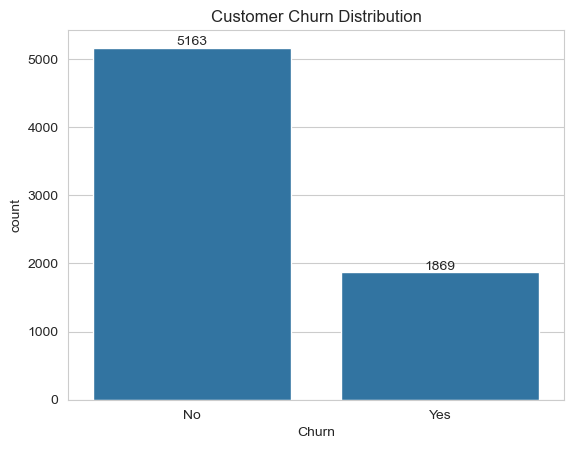

<Figure size 1000x500 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [35]:
#plotting a bar chart for churn customers and it's count

ax = sns.countplot(x = "Churn", data = df)
plt.title("Customer Churn Distribution")
for container in ax.containers:
    ax.bar_label(container)
plt.figure(figsize=(10,5))
plt.show()
plt.tight_layout()

### Insights
The dataset shows that a significantly larger proportion of customers are retained compared to customers who churned. However, the churned customer segment still represents a substantial business concern due to its direct impact on recurring revenue and acquisition costs.

### Business Interpretation

Although most customers stay with the company, customer attrition remains sufficiently high to require targeted retention strategies.

### Recommendation

Focus retention efforts on identifying high-risk customer groups before churn occurs.

## Customer Churn Analysis by Contract Type

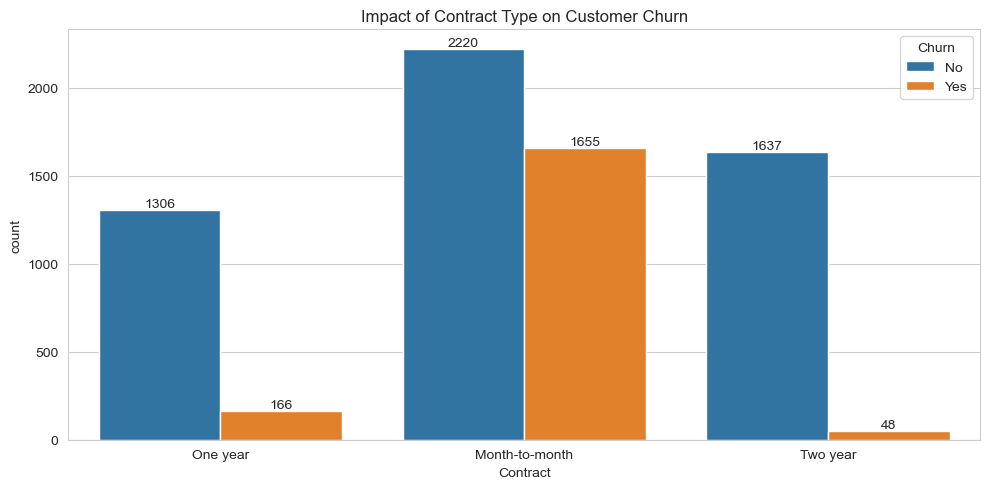

In [28]:
#plotting a bar chart for Contract vs Churn
plt.figure(figsize=(10,5))
ax = sns.countplot(x = "Contract", hue = "Churn", data = df)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Impact of Contract Type on Customer Churn")
plt.tight_layout()

### Insight

Customers enrolled in month-to-month contracts exhibit significantly higher churn rates than customers on one-year and two-year contracts.

### Business Interpretation

Short-term contracts provide lower switching barriers, increasing customer mobility and reducing long-term commitment.

### Recommendation

Encourage migration toward long-term plans through:

1). Discounted annual subscriptions    
2). Loyalty benefits    
3). Renewal incentives    
4). Bundled packages.    

## Relationship Between Customer tenure and Churn

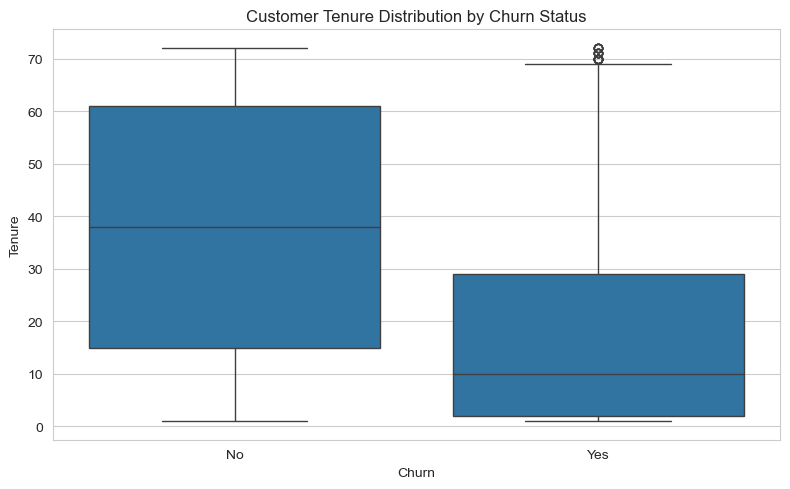

In [30]:
#plotting a bar chart for tenure vs Churn 

plt.figure(figsize=(8,5))
sns.boxplot(x = "Churn",y = "Tenure", data = df)
plt.title("Customer Tenure Distribution by Churn Status")
plt.tight_layout()

### Insight

Customers with lower tenure demonstrate noticeably higher churn behavior compared to long-tenure customers. Customers who remain longer with the company tend to exhibit stronger loyalty and lower cancellation rates.

### Business Interpretation

The early customer lifecycle appears to be the most vulnerable period for churn.

### Recommendation

Strengthen:

1). Onboarding programs     
2). Customer engagement    
3). Early support initiatives    

especially during the first few months.

## Correlation Heatmap of Key Customer Features

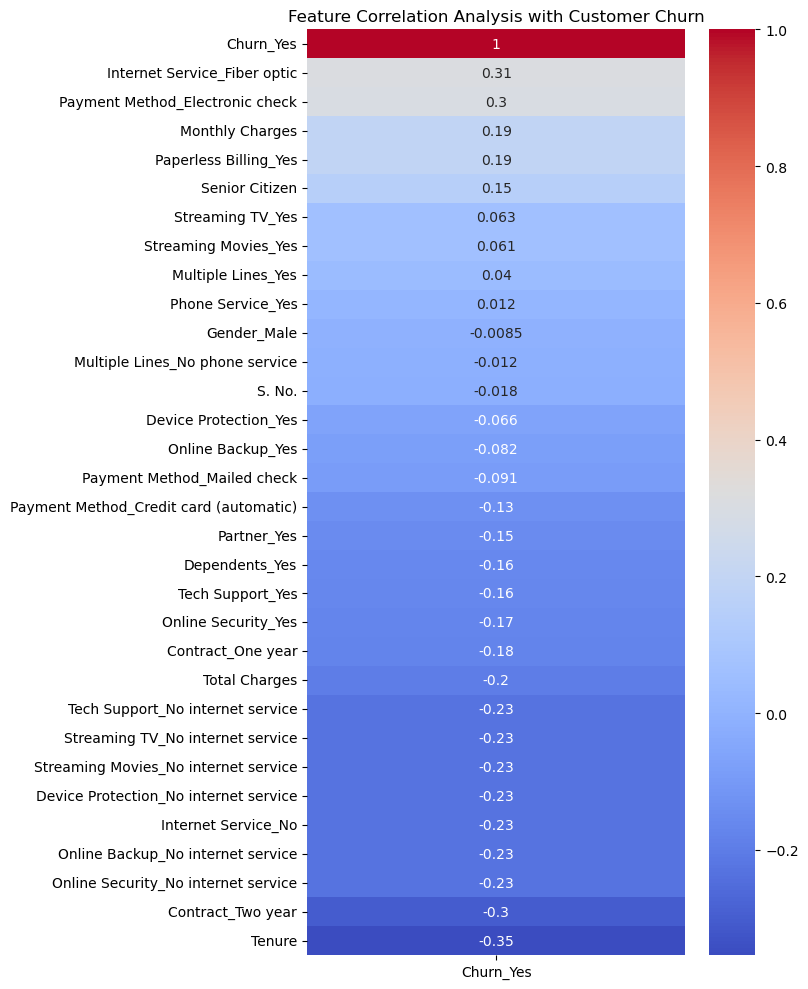

In [25]:
df_encoded = pd.get_dummies(df, drop_first=True)

corr = df_encoded.corr()

churn_corr = corr['Churn_Yes'].sort_values(ascending=False)

plt.figure(figsize=(8,10))
sns.heatmap(
    churn_corr.to_frame(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Feature Correlation Analysis with Customer Churn")
plt.tight_layout()
plt.show()

### Insight

The heatmap indicates that longer tenure and long-term contracts are negatively associated with churn, while higher monthly charges, month-to-month contracts, and certain service/payment patterns demonstrate stronger positive association with churn.

### Business Interpretation

Customer retention appears closely tied to customer commitment duration and pricing structure.

### Recommendation

Strengthen long-term customer engagement strategies and proactively target customers exhibiting high-risk correlation patterns.

## Impact of Monthly Charges on Customer Churn

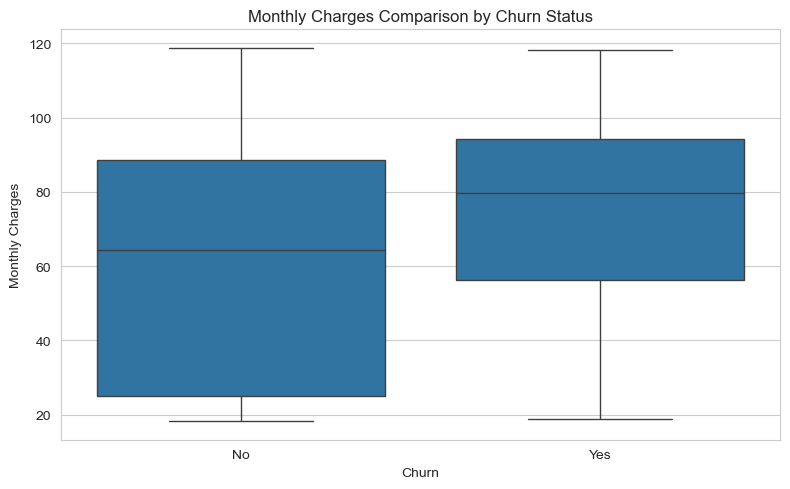

In [31]:
#plotting a bar chart for Churn vs Monthly Charges

plt.figure(figsize=(8,5))
sns.boxplot(x ="Churn",y ="Monthly Charges", data = df)
plt.title("Monthly Charges Comparison by Churn Status")
plt.tight_layout()

### Insight

Customers who churn generally show higher monthly charges than retained customers. Higher recurring costs appear to be associated with increased churn probability.

### Business Interpretation

Price sensitivity may influence customer satisfaction and encourage switching behavior.

### Recommendation

Consider:

1). Pricing optimization    
2). Bundled offerings    
3). Loyalty discounts    
4). Premium service justification    

for higher-paying customers.

## Influence of Payment Method on Customer Churn 

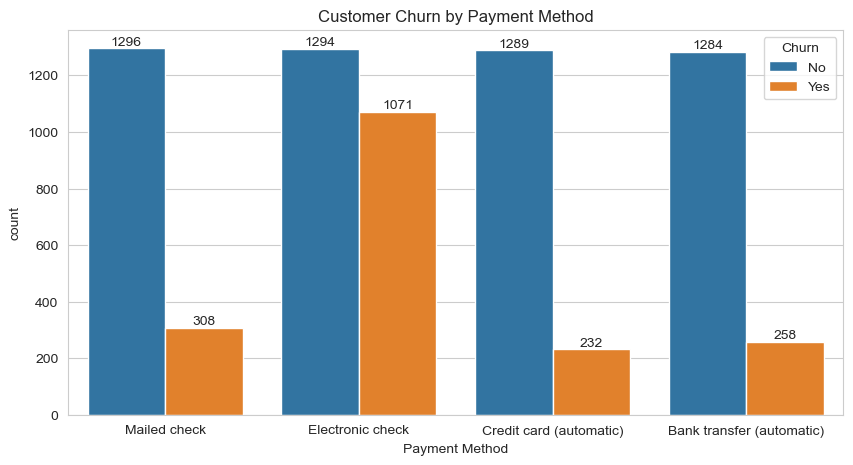

<Figure size 640x480 with 0 Axes>

In [32]:
#plotting a bar chart for payment Method vs Churn 

plt.figure(figsize=(10,5))
plt.title("Customer Churn by Payment Method")
ax = sns.countplot(x="Payment Method", hue="Churn", data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.show()
plt.tight_layout()

### Insight

Customers using electronic check payment methods demonstrate the highest churn behavior compared with customers using automatic bank transfers, credit card autopay, or mailed checks.

### Business Interpretation

Payment behavior appears strongly associated with customer retention. Customers using automated payment systems tend to exhibit greater stability and long-term commitment.

### Recommendation

Encourage customers to adopt:

1). Credit card autopay    
2). Bank transfer autopay    
3). Automatic billing incentives    

to improve retention and reduce churn risk.

## Customer Churn Across Internet Service Cateogries

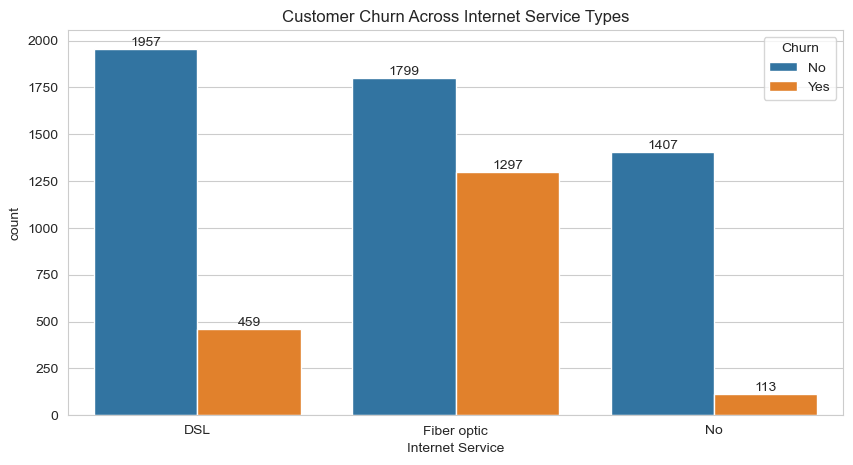

<Figure size 640x480 with 0 Axes>

In [33]:
#plotting a bar chart for internet Service vs Churn 

plt.figure(figsize=(10,5))
ax = sns.countplot(x="Internet Service", hue= "Churn", data =df)
plt.title("Customer Churn Across Internet Service Types")
for container in ax.containers:
    ax.bar_label(container)
plt.show()
plt.tight_layout()

### Insight

Customers using fiber optic internet service exhibit substantially higher churn rates than DSL and non-internet users.

### Business Interpretation

This pattern may indicate issues related to:

1). Pricing    
2). Service quality    
3). Customer expectations    
4). Competitive alternatives     

### Recommendation

Conduct deeper analysis into fiber customer experience, complaints, and service performance.

## Distribution Analysis of Monthly Customer Charges

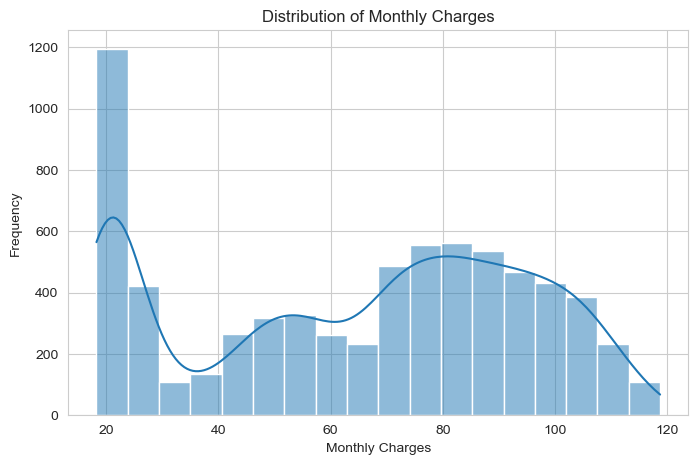

<Figure size 640x480 with 0 Axes>

In [34]:
plt.figure(figsize = (8,5))
sns.histplot(df["Monthly Charges"], kde  = True)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()
plt.tight_layout()

### Insight

Monthly customer charges display a broad distribution, indicating substantial variation in customer spending behavior across the customer base.

### Business Interpretation

The business serves multiple pricing segments ranging from lower-cost users to premium-paying customers.

### Recommendation

Create customer segmentation strategies based on spending patterns to deliver more personalized offers and retention campaigns.

### Final Executive Insights

1. Customer churn appears to be primarily driven by customer commitment level. Month-to-month contract customers consistently demonstrate substantially higher churn behavior than customers enrolled in one-year and two-year contracts, indicating that contractual stability is a critical retention factor.

2. Customer lifecycle duration shows a strong relationship with churn outcomes. Customers with shorter tenure are significantly more likely to discontinue services, suggesting that churn risk is concentrated during the early stages of the customer journey.

3. Pricing dynamics influence customer retention patterns. Customers exhibiting higher monthly charges tend to demonstrate increased churn probability, indicating potential pricing sensitivity or perceived imbalance between service cost and delivered value.

4. Service portfolio characteristics contribute meaningfully to churn behavior. Fiber optic customers display comparatively elevated churn rates, which may reflect underlying issues related to pricing competitiveness, customer expectations, or service experience.

5. Payment behavior acts as an important behavioral indicator of churn. Customers using electronic check payment methods exhibit noticeably higher attrition tendencies compared with customers using automated payment systems, suggesting that billing preferences correlate with retention stability.

6. Correlation analysis indicates that churn is not driven by a single variable but by an interaction of customer tenure, contract commitment, pricing structure, service selection, and payment behavior. This highlights the multi-dimensional nature of customer retention challenges.

7. Demographic variables such as gender demonstrate relatively limited explanatory power compared with behavioral and service-related factors, implying that retention strategies should prioritize customer behavior and service engagement over broad demographic segmentation.

### Strategic Business Recommendations

1. Develop targeted migration campaigns encouraging month-to-month customers to transition toward longer-term subscription plans through contract incentives and loyalty benefits.

2. Strengthen early-stage customer retention programs, particularly during the initial customer lifecycle period, through onboarding optimization, proactive support, and engagement initiatives.

3. Reassess pricing strategies for higher-billing customer segments by improving value communication, introducing personalized offers, or optimizing service bundles.

4. Conduct focused operational analysis on fiber optic customer segments to identify potential service quality, pricing, or customer experience drivers contributing to elevated churn behavior.

5. Increase adoption of automated payment mechanisms by introducing incentives for autopay enrollment and simplifying digital billing processes.

6. Implement churn risk monitoring frameworks leveraging high-impact variables such as contract type, tenure, pricing metrics, and payment behavior to enable proactive retention interventions.